# packed_v1 leaderboard — visual weigh-in

Focused view of the `packed_v1` regime (canonical 4k-step horizon).

Two views:
1. **σ-anchored leaderboard** (bar chart): mean ± std per (optimizer, rank) cell, with AdamW's multi-seed σ-band as the reference. Single-seed cells render without error bars.
2. **Trajectory panel** (`standard_sweep_figure`): eval-loss curves over training, with AdamW's seed=0 η-sweep as the left-panel reference.

**σ_AdamW(packed_v1):** 0.0011 at r=16, 0.0017 at r=64 (from `adamw_multiseed_packed_4k_blackwell`, 4 seeds at η=3e-4 + seed=0 lr-sweep). All Δ claims in the writeups should be quoted in σ-units against this anchor.


In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    standard_sweep_figure,
)
from lora_playground.loader import load_runs, inventory_runs, render_inventory

# Force re-parse of log files. The plot_utils cache keys runs by file
# (mtime, size); when the loader code changes (e.g., adding init_b
# backfill) the cached cfgs are stale even though the files haven't moved.
# Clear once on startup so the next load_runs call re-reads everything.
import lora_playground.plot_utils as _pu
_pu._LOAD_RUN_CACHE.clear()
_pu._LOAD_SWEEP_CACHE.clear()
print(f"Cleared run/sweep caches — load_runs will re-parse all log files.")

## Audit — what's loadable vs invisible

In [10]:
print(render_inventory(inventory_runs('../logs')))

Loaded 194 of 202 groups on disk.

NO run_info/ (13) — files present but missing run_info/ dir, invisible to load_runs:
  adamw_sanity_packed_v1_4k
  bench
  bench_a100
  bench_profile_packed_v1
  bench_profile_walltime
  chord_direction_k3_lr5e-3_r16r64_blackwell.contaminated_v1
  chord_tight_k3_r16_lr6e-2_4k_blackwell.contaminated_v1
  chord_tight_k3_r64_lr1e-3_4k_blackwell.contaminated_v1
  ddp_smoke
  integration_higham_test
  profile_polar_components
  r256_chord_direction_k1_lrsweep_4k_blackwell.contaminated_v1
  r256_chord_lr5e-3_refinement_blackwell.contaminated_v1

UNKNOWN OPTIMIZERS (3) — in logs but missing from OPTIM_COLORS, will be dropped by any cell that filters on it:
  kfac-lora
  svd-cumulative-adamw
  svd-step-adamw

Coverage: 127 (optimizer, rank, mult) cells
PINNED at lr-range boundary (44) — extension sweep recommended:
  adam-clip-product-lora            r=16          best_lr=3e-04 (final=0.7555)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora   

## Load packed_v1 runs

Reference = AdamW lr-sweep (seed=0). Candidates = chord/polar variants at lr=3e-3.

In [11]:
# Reference: AdamW packed_v1, ALL seeds. The library aggregates per-η
# (left panel: vertical seed-σ error bars) and per-step at best η (right
# panel: shaded ±σ band around the mean trajectory). Partial-horizon runs
# are auto-filtered (`min_step` inferred from cfg.max_steps).
ref_runs = load_runs(
    where={'optimizer': 'adamw', 'data_pipeline_version': 'packed_v1'},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'reference AdamW packed_v1 (all seeds): {len(ref_runs)} runs')
from collections import Counter
print(f'  seeds per η: ' + ', '.join(
    f"η={lr:.0e}:{n}" for lr, n in
    Counter(cfg['lr'] for cfg, _ in ref_runs).most_common()))

# Candidates: chord/polar family only.
# adam-muon-lora and muon-lora are excluded — at their best lr they sit
# ~+0.012 above AdamW (r=16) and ~+0.010 (r=64), far outside the chord
# variants' Δ range. Including them just stretches plot range / legend
# without informing the chord-vs-AdamW comparison.
CANDIDATE_FAMILY = [
    'adam-polar-product-lora-coupled-spectral-chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening',
    'adam-polar-product-lora-coupled-spectral-chord-direction',
    'adam-polar-product-lora-coupled',  # frob (AdaMuon parent, no chord-tight ρ)
]
cand_runs = load_runs(
    where={'optimizer': CANDIDATE_FAMILY, 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'candidate packed_v1 @ 4k: {len(cand_runs)} runs')
for cfg, evs in cand_runs:
    last = evs[-1] if evs else {}
    pic = cfg.get('_derived', {}).get('effective_picard_iters')
    print(f"  {cfg['optimizer']:55s} r={cfg.get('lora_r')} lr={cfg.get('lr'):.0e} k={pic} "
          f"step={last.get('step')} eval={last.get('eval_loss'):.4f}")


reference AdamW packed_v1 (all seeds): 24 runs
  seeds per η: η=3e-04:10, η=1e-04:6, η=3e-05:3, η=1e-05:2, η=1e-03:2, η=3e-03:1
candidate packed_v1 @ 4k: 128 runs
  adam-polar-product-lora-coupled-spectral-chord-tight    r=16 lr=5e-03 k=1 step=400 eval=0.5797
  adam-polar-product-lora-coupled-spectral-chord-tight    r=16 lr=7e-03 k=1 step=400 eval=0.5775
  adam-polar-product-lora-coupled-spectral-chord-tight    r=64 lr=5e-03 k=1 step=400 eval=0.5782
  adam-polar-product-lora-coupled-spectral-chord-tight    r=64 lr=7e-03 k=1 step=400 eval=0.5784
  adam-polar-product-lora-coupled-spectral-chord-tight    r=256 lr=7e-03 k=1 step=200 eval=0.5978
  adam-polar-product-lora-coupled-spectral-chord-tight    r=256 lr=3e-03 k=1 step=2000 eval=0.5311
  adam-polar-product-lora-coupled-spectral-chord-tight    r=256 lr=3e-02 k=1 step=2000 eval=0.5710
  adam-polar-product-lora-coupled-spectral-chord-tight    r=256 lr=1e-03 k=1 step=2000 eval=0.5443
  adam-polar-product-lora-coupled-spectral-chord-tight

## Group key and color map

For AdaMuon-parent runs (no chord-tight ρ), distinguish by Picard iter count to separate the `frob_k=1` and `frob_k=3` cells. For chord-family variants the optimizer slug alone is the discriminator.

In [ ]:
# Short legend labels with explicit Picard k. Leaderboard now contains both
# k=1 and k=3 cells for the same optimizer slug — always embed k. Init[AB]
# (B initialized non-zero via PiSSA-style symmetric init) is tagged
# separately so it shows as a distinct series alongside the default
# Init[A] (B=0 at init).
SHORT = {
    'adam-polar-product-lora-coupled-spectral-chord-tight':                'chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening':   'chord-tight (no-whiten)',
    'adam-polar-product-lora-coupled-spectral-chord-direction':            'chord-direction',
}


def group_key(cfg):
    """Group label including k where it matters, and Init tag when non-default."""
    opt = cfg['optimizer']
    k = cfg.get('_derived', {}).get('effective_picard_iters', '?')
    init_b = cfg.get('lora_init_b') or 'zero'
    init_tag = ('' if init_b == 'zero'
                else ' [Init[AB]]' if init_b == 'symmetric'
                else f' [{init_b}]')
    if opt == 'adam-polar-product-lora-coupled':
        return f'frob k={k}{init_tag}'
    base = SHORT.get(opt, opt)
    return f'{base} k={k}{init_tag}'


# Six maximally-distinct hues — one per (variant, k) in the competitive set.
# Marker shape is also redundantly encoded per variant for mono / colorblind
# readability. Init[AB] series share the variant's hue but use a distinct
# marker so they read as the same variant under a different init.
color_map = {
    'chord-tight k=1':              '#1f77b4',  # tab:blue
    'chord-tight k=3':              '#d62728',  # tab:red
    'chord-tight (no-whiten) k=1':  '#17becf',  # tab:cyan
    'chord-tight (no-whiten) k=3':  '#2ca02c',  # tab:green
    'chord-direction k=1':          '#ff7f0e',  # tab:orange
    'chord-direction k=3':          '#9467bd',  # tab:purple
    # Init[AB] series — same hues as the Init[A] counterparts (variant
    # identity), distinct marker (below) for the init scheme.
    'chord-tight k=1 [Init[AB]]':              '#1f77b4',
    'chord-tight k=3 [Init[AB]]':              '#d62728',
    'chord-tight (no-whiten) k=1 [Init[AB]]':  '#17becf',
    'chord-tight (no-whiten) k=3 [Init[AB]]':  '#2ca02c',
    'chord-direction k=1 [Init[AB]]':          '#ff7f0e',
    'chord-direction k=3 [Init[AB]]':          '#9467bd',
    # frob (supplementary):
    'frob k=1':                     '#bcbd22',  # olive
    'frob k=3':                     '#7f7f7f',  # gray
}

marker_map = {
    'chord-tight k=1':              'o',
    'chord-tight k=3':              'o',
    'chord-tight (no-whiten) k=1':  's',
    'chord-tight (no-whiten) k=3':  's',
    'chord-direction k=1':          'D',
    'chord-direction k=3':          'D',
    # Init[AB] markers: distinct so the two init schemes are separable at
    # the same hue.
    'chord-tight k=1 [Init[AB]]':              'x',
    'chord-tight k=3 [Init[AB]]':              'x',
    'chord-tight (no-whiten) k=1 [Init[AB]]':  '+',
    'chord-tight (no-whiten) k=3 [Init[AB]]':  '+',
    'chord-direction k=1 [Init[AB]]':          '*',
    'chord-direction k=3 [Init[AB]]':          '*',
    'frob k=1':                     '^',
    'frob k=3':                     'v',
}

## Standard sweep figure — competitive vs supplementary

Variant + k split (every lr in the sweep is kept).

- **Competitive**: all six chord-family (variant, k) cells. None is strictly dominated at every rank — at r=64, k=1 and k=3 are tied for no-whiten and direction (Δ ≤ 1σ); the only clear k-dominance is no-whiten at r=16 (k=3 better by ~2.4σ). Six distinct hues, marker shape redundantly encodes variant family.
- **Supplementary**: frob (AdaMuon parent), both k. Different family — kept for context.

NaN / early-killed runs fold into `split_diverged` (NaN eval_loss → ∞; runs that die in the first 10% of training counted as diverged) so they no longer warp the y-axis or sneak into the trajectory panel.


competitive: 124 runs across 65 (variant, k, r, lr) cells
supplementary: 4 runs across 4 (variant, k, r, lr) cells
  [filtered diverged] chord-direction k=3 η=1e-02 max=0.595 final=0.595
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 3 run(s) below min_step=4000:
    chord-direction k=3 η=5e-03    step=1200 final-so-far=0.5524
    chord-tight k=1 η=5e-03        step=400 final-so-far=0.5797
    chord-tight k=1 η=7e-03        step=400 final-so-far=0.5775
  [filtered diverged] chord-direction k=3 η=5e-03 max=0.593 final=0.593
  [auto] min_step inferred from cfg['max_steps']: 4000
  [filtered partial from left panel] 8 run(s) below min_step=4000:
    chord-direction k=3 η=1e-03    step=3800 final-so-far=0.5266
    chord-tight (no-whiten) k=3 η=3e-02 step=2200 final-so-far=0.5721
    chord-tight k=1 η=1e-02        step=2800 final-so-far=0.5252
    chord-tight k=1 η=3e-02        step=2800 final-so-far=0.5396
    chord-tight k=1 η=3e-03        step

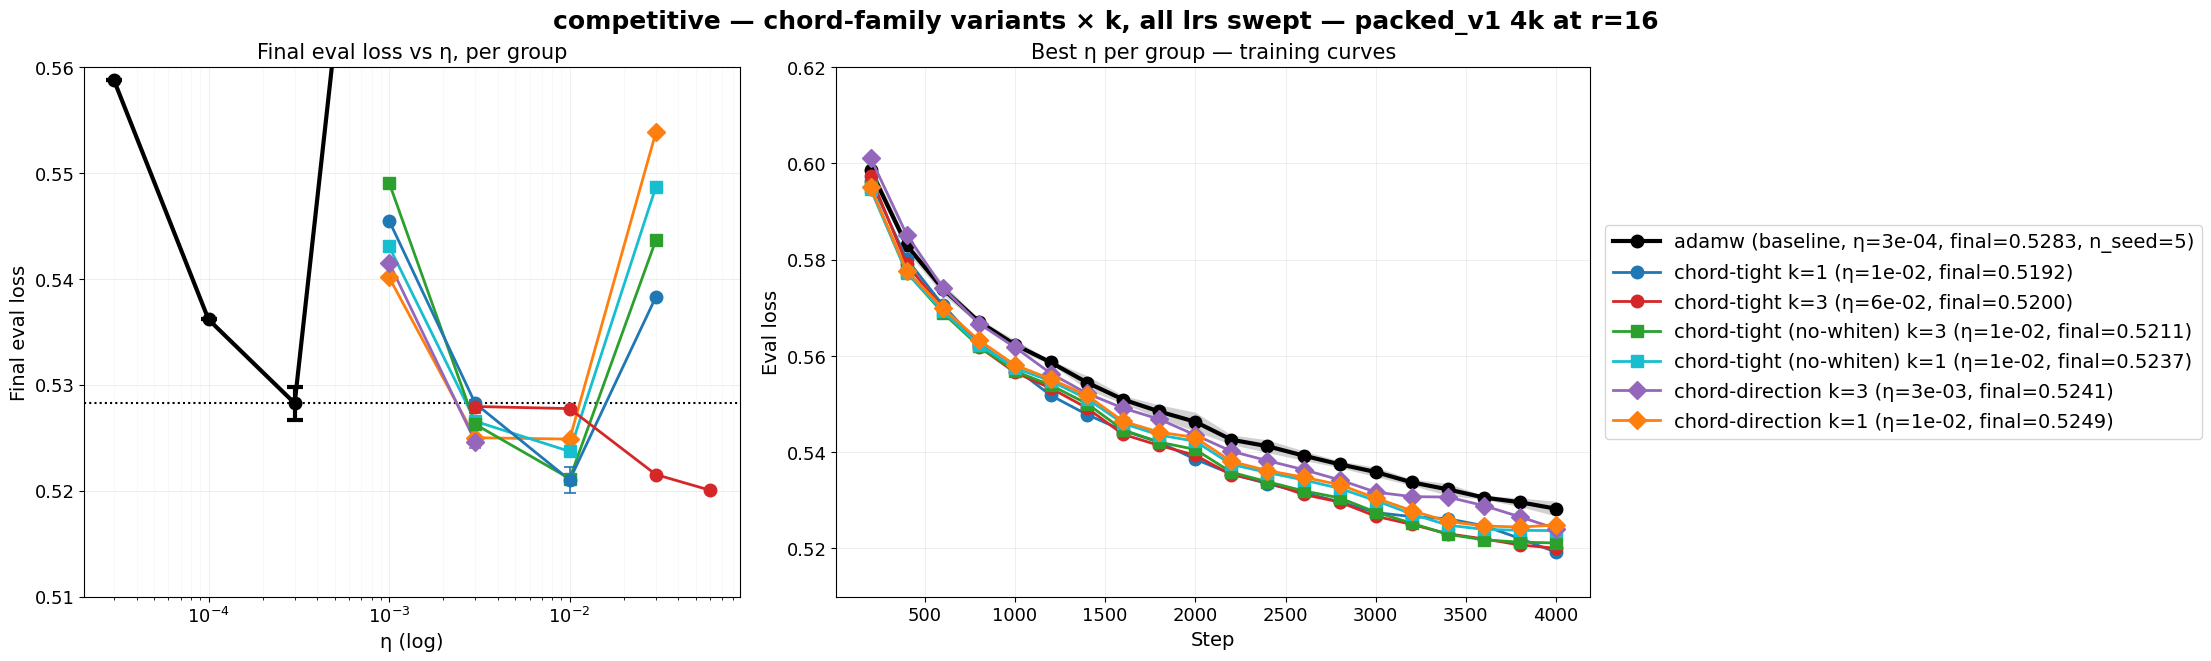

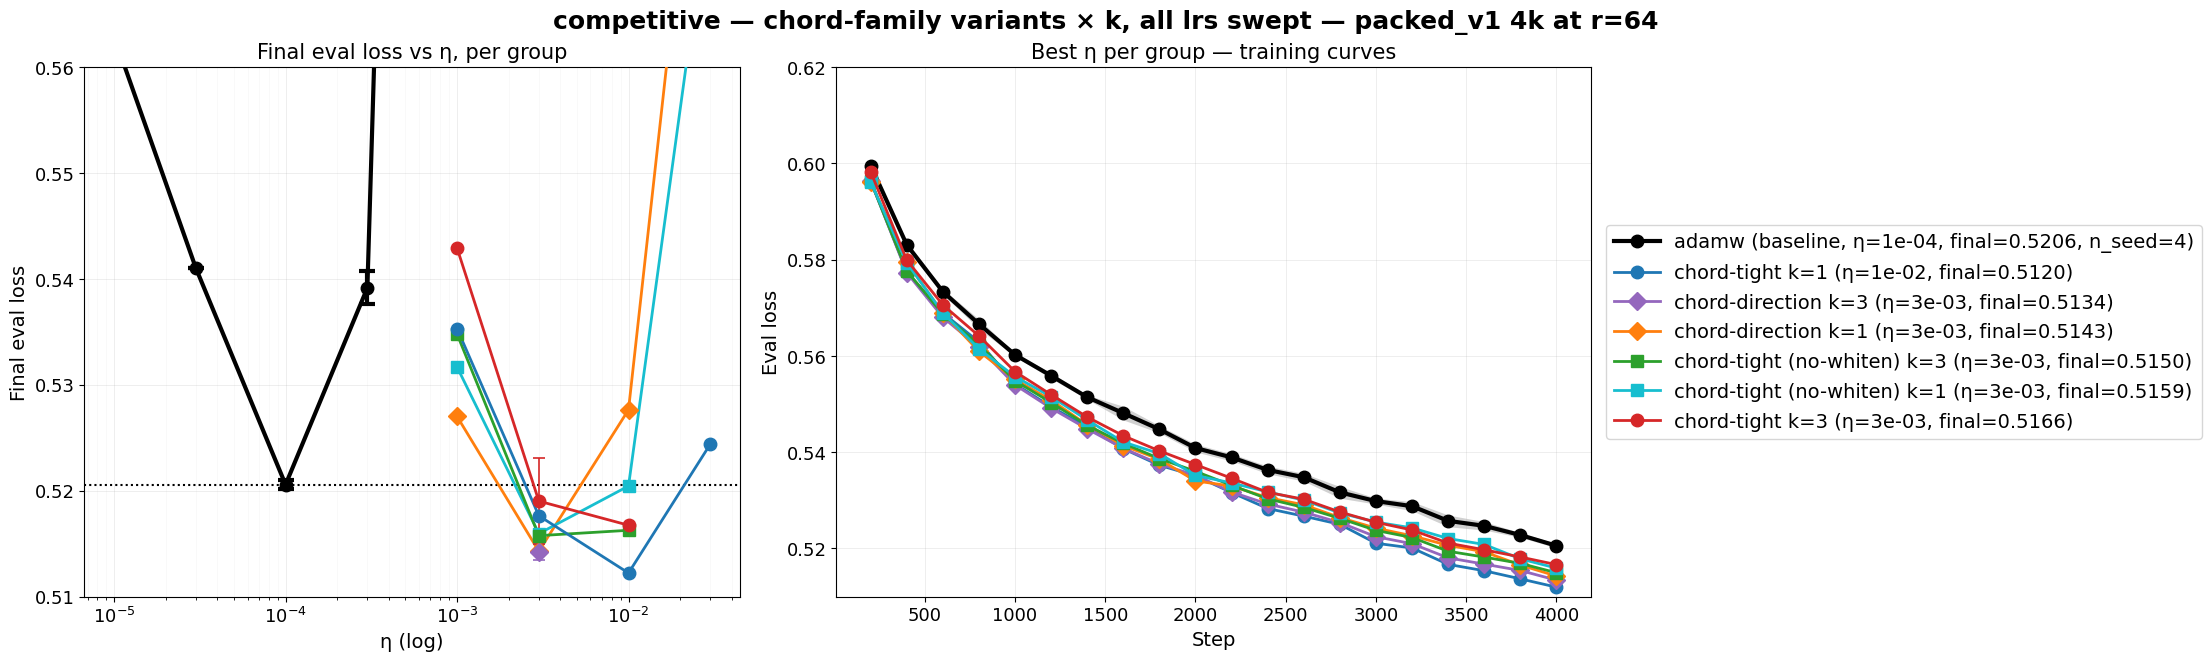

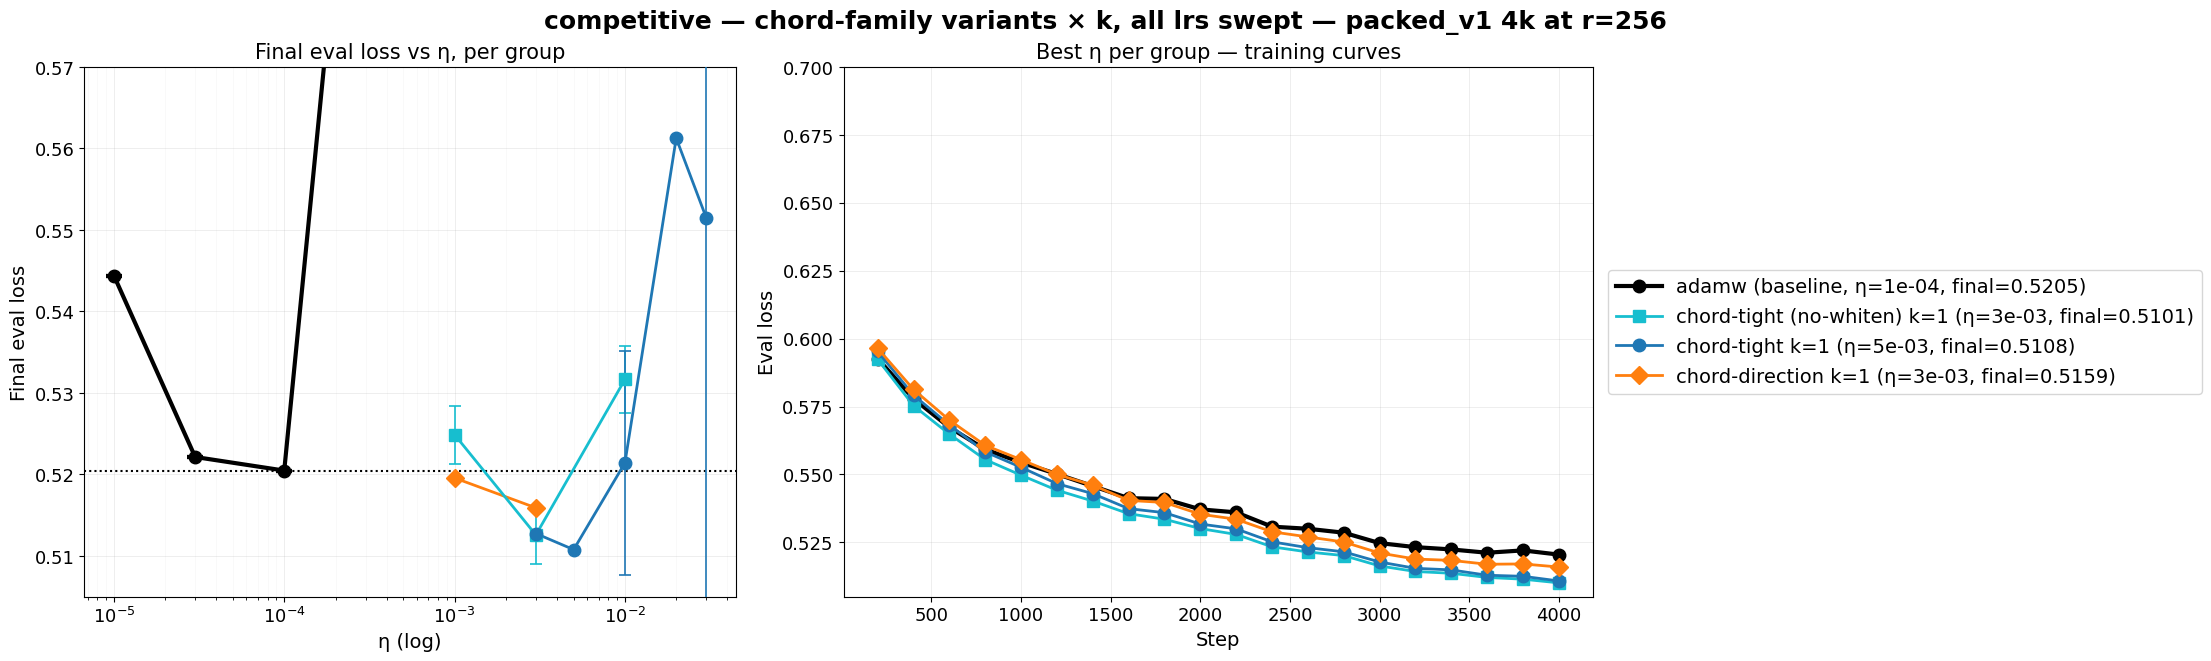

In [13]:
# Competitive / supplementary split by (variant, k). All lrs kept per cell.
WHITEN   = 'adam-polar-product-lora-coupled-spectral-chord-tight'
NOWHITEN = 'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening'
DIRECT   = 'adam-polar-product-lora-coupled-spectral-chord-direction'

COMPETITIVE_VARIANT_K = {
    (WHITEN,   1), (WHITEN,   3),
    (NOWHITEN, 1), (NOWHITEN, 3),
    (DIRECT,   1), (DIRECT,   3),
}

def is_competitive(cfg):
    k = cfg.get('_derived', {}).get('effective_picard_iters')
    return (cfg['optimizer'], k) in COMPETITIVE_VARIANT_K

competitive_runs   = [r for r in cand_runs if is_competitive(r[0])]
supplementary_runs = [r for r in cand_runs if not is_competitive(r[0])]

def _cell_count(runs):
    return len({(c['optimizer'],
                 c.get('_derived', {}).get('effective_picard_iters'),
                 c['lora_r'], c['lr']) for c, _ in runs})

print(f'competitive: {len(competitive_runs)} runs across {_cell_count(competitive_runs)} (variant, k, r, lr) cells')
print(f'supplementary: {len(supplementary_runs)} runs across {_cell_count(supplementary_runs)} (variant, k, r, lr) cells')

# Per-rank ylims — r=256 best is below 0.51 (no-whiten r=256 hit 0.5101),
# so r=256 widens the bottom; r∈{16,64} keep the tight window.
YLIM_LEFT_BY_R  = {16: (0.510, 0.560), 64: (0.510, 0.560), 256: (0.505, 0.570)}
YLIM_RIGHT_BY_R = {16: (0.510, 0.620), 64: (0.510, 0.620), 256: (0.505, 0.700)}

# Set False to show raw η on the x-axis (default — easier to read
# pinned-vs-interior). True for η/η★-aligned visual lr-sweep shape.
NORMALIZE_X_TO_OPTIMUM = False

def _render(runs, suptitle):
    results = standard_sweep_figure(
        runs,
        group_key_fn=group_key,
        color_map=color_map,
        reference_runs=ref_runs,
        suptitle=suptitle,
        same_value_axes=('lora_plus_multiplier',),
        marker_map=marker_map,
        figsize=(22, 6.5),
        x_tick_step=500,
        normalize_x_to_optimum=NORMALIZE_X_TO_OPTIMUM,
    )
    for fig, axes, _n_keep, _n_drop in results:
        # Infer rank from the figure's suptitle (standard_sweep_figure
        # stamps "r=<value>" into the suptitle when splitting by lora_r).
        rank = None
        title = fig._suptitle.get_text() if fig._suptitle else ''
        for r_try in (256, 128, 64, 32, 16):
            if f'r={r_try}' in title or f'lora_r={r_try}' in title:
                rank = r_try
                break
        ylim_l = YLIM_LEFT_BY_R.get(rank, (0.505, 0.570))
        ylim_r = YLIM_RIGHT_BY_R.get(rank, (0.505, 0.700))
        axes[0].set_ylim(*ylim_l)
        axes[1].set_ylim(*ylim_r)
    return results

_render(competitive_runs,
        'competitive — chord-family variants × k, all lrs swept — packed_v1 4k')
plt.show()


### Supplementary — frob parent

`adam-polar-product-lora-coupled` (frob / AdaMuon parent, no chord-tight ρ). Different family from the chord variants — context only.


  [auto] min_step inferred from cfg['max_steps']: 4000
  [auto] min_step inferred from cfg['max_steps']: 4000


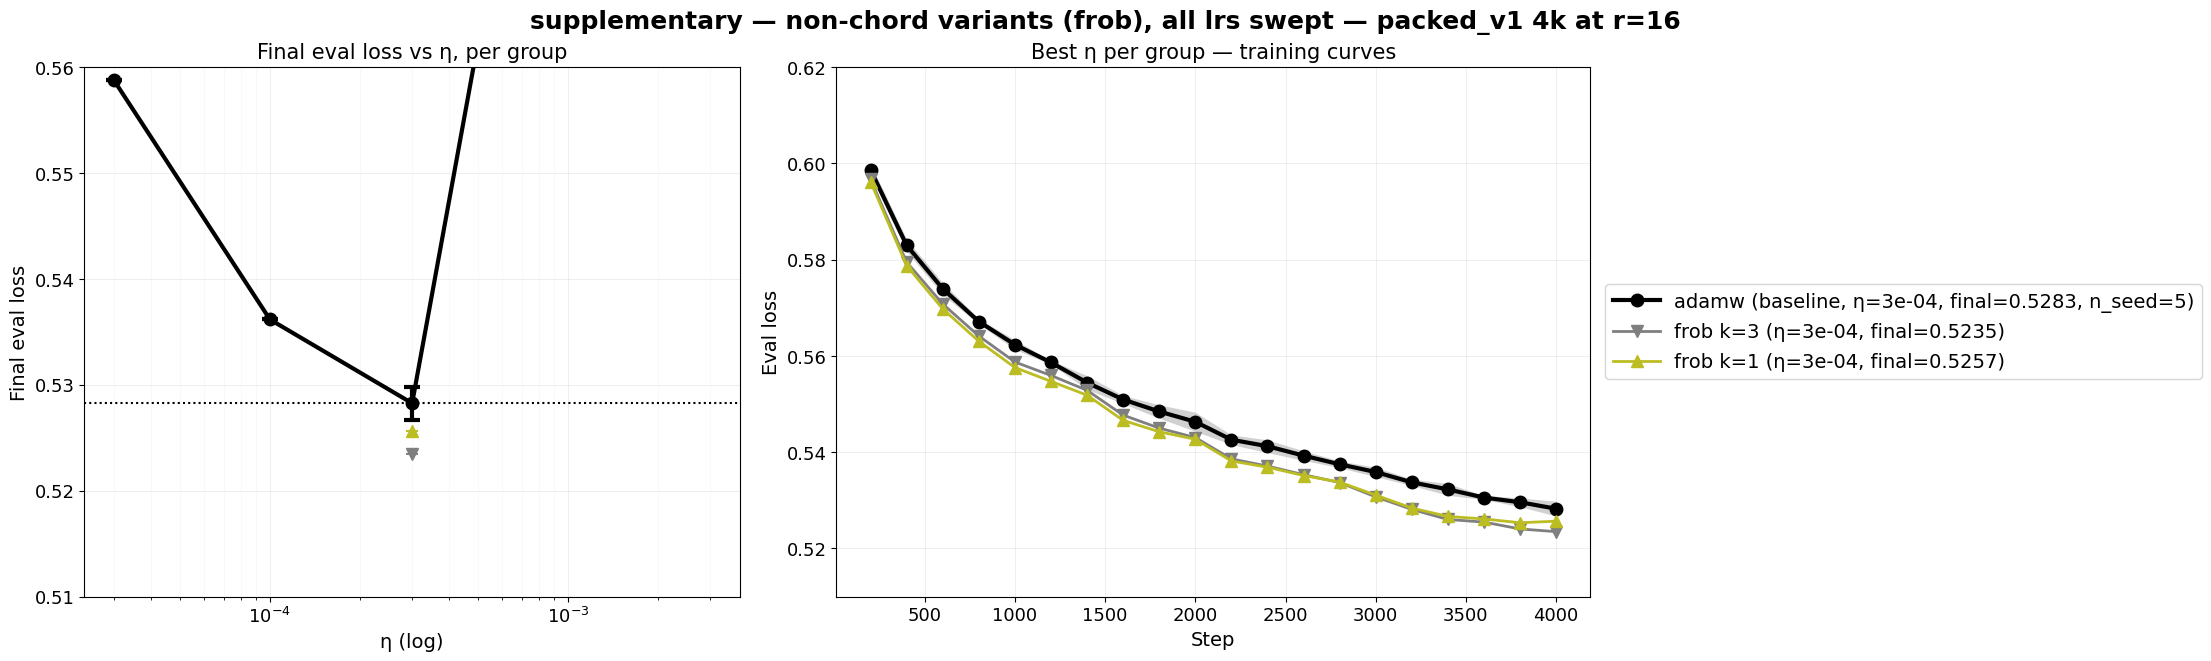

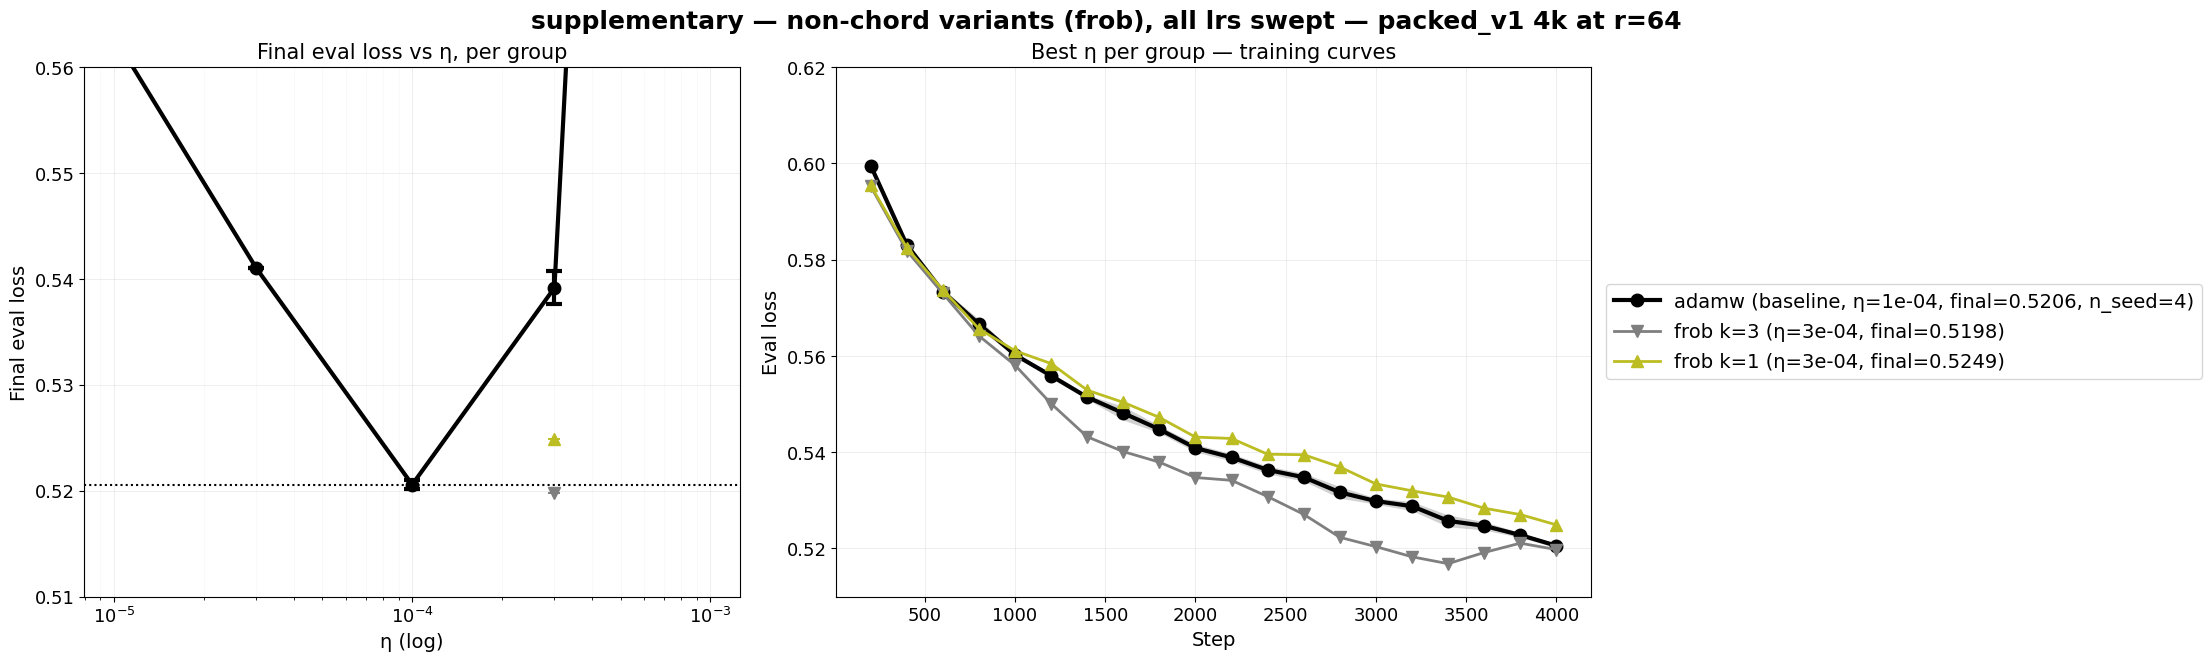

In [14]:
_render(supplementary_runs,
        'supplementary — non-chord variants (frob), all lrs swept — packed_v1 4k')
plt.show()
